In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("../..")

print(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(sys.path[0])

c:\Users\sujay\OneDrive\Desktop\PI_LABS\selfcheckgpt
c:\Users\sujay\OneDrive\Desktop\PI_LABS\selfcheckgpt


In [2]:
import os

print(os.listdir(PROJECT_ROOT))

['.git', '.gitignore', '.pytest_cache', 'belief_stability', 'configs', 'demo', 'DESCRIPTION.txt', 'experiments', 'LICENSE', 'MANIFEST.in', 'pytest.ini', 'README.md', 'selfcheckgpt', 'setup.py', 'tests', 'venv']


In [3]:
import importlib.util

print(importlib.util.find_spec("selfcheckgpt"))

ModuleSpec(name='selfcheckgpt', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001EBC630DEB0>, origin='c:\\Users\\sujay\\OneDrive\\Desktop\\PI_LABS\\selfcheckgpt\\selfcheckgpt\\__init__.py', submodule_search_locations=['c:\\Users\\sujay\\OneDrive\\Desktop\\PI_LABS\\selfcheckgpt\\selfcheckgpt'])


In [4]:
try:
    from selfcheckgpt.modeling_selfcheck import SelfCheckNLI
    print("SUCCESS")
except Exception as e:
    import traceback
    traceback.print_exc()

c:\Users\sujay\OneDrive\Desktop\PI_LABS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SUCCESS


In [5]:
import torch
import transformers
import bert_score
import spacy

print("All OK")

All OK


In [6]:
from pathlib import Path

from belief_stability.belief_cache import BeliefCache
from belief_stability.config import BeliefStabilityConfig
from belief_stability.matcher.semantic import SemanticMatcher
from belief_stability.pipeline import BeliefStabilityPipeline
from belief_stability.sentence_runner import SentenceBeliefRunner

# Belief Stability now runs in two stages:
#   1. OFFLINE (one-time, GPU): experiments/build_belief_cache.py runs REBEL
#      once per unique sentence/sampled-passage and caches canonicalized
#      Beliefs to disk. This used to happen inline in the loop below, once
#      PER SENTENCE, which is what caused the ~30hr / ~500s-per-example
#      runtime seen in this notebook's earlier run (see the aborted cell
#      further down - 2/238 examples in 17 minutes).
#   2. ONLINE (this notebook, GPU-free): load the cache and run matching +
#      scoring only. No REBEL, no MiniLM, no model calls in the loop below.

BELIEF_CACHE_PATH = Path(PROJECT_ROOT) / "experiments" / "results" / "belief_cache.pkl"
BELIEF_CONFIG_PATH = Path(PROJECT_ROOT) / "configs" / "default.yaml"

if not BELIEF_CACHE_PATH.exists():
    raise FileNotFoundError(
        f"No belief cache found at {BELIEF_CACHE_PATH}.\n"
        "Build it once (offline, GPU, ~15-25 min on an RTX 2050) with:\n"
        "    python experiments/build_belief_cache.py --resume\n"
        "Everything in this notebook after that is GPU-free and reruns in seconds."
    )

belief_config = BeliefStabilityConfig.from_yaml(BELIEF_CONFIG_PATH)
belief_cache = BeliefCache.load(BELIEF_CACHE_PATH)

embeddings_path = BELIEF_CACHE_PATH.with_suffix(BELIEF_CACHE_PATH.suffix + ".embeddings.pkl")
semantic_matcher = (
    SemanticMatcher.load(embeddings_path) if embeddings_path.exists() else SemanticMatcher()
)

belief_pipeline = BeliefStabilityPipeline(config=belief_config, semantic_matcher=semantic_matcher)
bs_runner = SentenceBeliefRunner(pipeline=belief_pipeline)

print(f"Loaded belief cache: {len(belief_cache)} examples, scoring_method={belief_config.scoring_method}")

[INFO] belief_stability.belief_cache - Loaded belief cache: 238 examples from c:\Users\sujay\OneDrive\Desktop\PI_LABS\selfcheckgpt\experiments\results\belief_cache.pkl


Loaded belief cache: 238 examples, scoring_method=bayesian


In [7]:
import pickle
import numpy as np
from scipy.stats import entropy
from tqdm import tqdm
from datasets import load_dataset

# SelfCheckGPT
- NLI variant (fast)

In [8]:
import torch
from selfcheckgpt.modeling_selfcheck import SelfCheckNLI

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
import torch

print("Torch :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())
print("CUDA Version :", torch.version.cuda)
print("GPU Count :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Torch : 2.11.0+cu128
CUDA Available : True
CUDA Version : 12.8
GPU Count : 1
GPU : NVIDIA GeForce RTX 2050


In [11]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [12]:
from selfcheckgpt.modeling_selfcheck import SelfCheckNLI

selfcheck = SelfCheckNLI(device=device)

print("SelfCheck Loaded Successfully")

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 32506.31it/s]


SelfCheck-NLI initialized to device cuda
SelfCheck Loaded Successfully


In [13]:
print(type(selfcheck))

<class 'selfcheckgpt.modeling_selfcheck.SelfCheckNLI'>


In [14]:
selfcheck = SelfCheckNLI(device=device)

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 18961.77it/s]


SelfCheck-NLI initialized to device cuda


## load `wiki_bio_gpt3_hallucination` data

In [15]:
dataset = load_dataset("potsawee/wiki_bio_gpt3_hallucination")
dataset = dataset['evaluation']

In [16]:
label_mapping = {
    'accurate': 0.0,
    'minor_inaccurate': 0.5,
    'major_inaccurate': 1.0,
}

In [17]:
human_label_detect_False   = {}
human_label_detect_False_h = {}
human_label_detect_True    = {}
for i_ in range(len(dataset)):
    dataset_i = dataset[i_]
    idx = dataset_i['wiki_bio_test_idx']
    raw_label = np.array([label_mapping[x] for x in dataset_i['annotation']])
    human_label_detect_False[idx] = (raw_label > 0.499).astype(np.int32).tolist()
    human_label_detect_True[idx]  = (raw_label < 0.499).astype(np.int32).tolist()
    average_score = np.mean(raw_label)
    if average_score < 0.99:
        human_label_detect_False_h[idx] = (raw_label > 0.99).astype(np.int32).tolist()

In [18]:
len(human_label_detect_False), len(human_label_detect_True), len(human_label_detect_False_h)

(238, 238, 206)

# Experimental Setup

In [19]:
def unroll_pred(scores, indices):
    unrolled = []
    for idx in indices:
        unrolled.extend(scores[idx])
    return unrolled

In [20]:
def get_PR_with_human_labels(preds, human_labels, pos_label=1, oneminus_pred=False):
    indices = [k for k in human_labels.keys()]
    unroll_preds = unroll_pred(preds, indices)
    if oneminus_pred:
        unroll_preds = [1.0-x for x in unroll_preds]
    unroll_labels = unroll_pred(human_labels, indices)
    assert len(unroll_preds) == len(unroll_labels)
    print("len:", len(unroll_preds))
    P, R, thre = precision_recall_curve(unroll_labels, unroll_preds, pos_label=pos_label)
    return P, R

In [21]:
def print_AUC(P, R):
    print("AUC: {:.2f}".format(auc(R, P)*100))

In [22]:
indices = [x['wiki_bio_test_idx'] for x in dataset] 

In [23]:
selfcheck_scores = {}

belief_scores = {}

for i in tqdm(range(len(dataset))):

    x = dataset[i]

    idx = x["wiki_bio_test_idx"]

    # -------------------------------
    # SelfCheckGPT
    # -------------------------------

    selfcheck_scores[idx] = selfcheck.predict(

        sentences=x["gpt3_sentences"],

        sampled_passages=x["gpt3_text_samples"],

    ).tolist()

    # -------------------------------
    # Belief Stability
    # GPU-free: reads canonicalized beliefs from the cache built
    # offline by build_belief_cache.py instead of re-running REBEL
    # here (that re-run-per-sentence loop is what produced the
    # KeyboardInterrupt a few cells below, at 2/238 examples).
    # -------------------------------

    if belief_cache.has(idx):

        entry = belief_cache.get(idx)

        belief_scores[idx] = bs_runner.run_from_cache(
            original_beliefs=entry.original_beliefs,
            sampled_beliefs=entry.sampled_beliefs,
            aggregation=belief_config.sentence_aggregation,
        )

    else:
        print(f"Warning: no cached beliefs for idx={idx}, skipping (run build_belief_cache.py first).")
        belief_scores[idx] = [0.0] * len(x["gpt3_sentences"])

100%|██████████| 238/238 [1:07:08<00:00, 16.93s/it]


In [24]:
idx = dataset[0]["wiki_bio_test_idx"]

print("=" * 80)

print("SELFCHECK")

print("=" * 80)

print(selfcheck_scores[idx])

print()

print("=" * 80)

print("BELIEF STABILITY")

print("=" * 80)

print(belief_scores[idx])

SELFCHECK
[0.8696355788037181, 0.9287474632263184, 0.9313702348619699, 0.9822565734386444, 0.2219625212783285, 0.48070281753316524, 0.889329245686531, 0.9217814788222313, 0.9570154577493668]

BELIEF STABILITY
[-0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334, -0.8333333333333334]


## Experiment1: Detecting False

In [25]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

In [26]:
# with human label, Detecting False
Prec, Rec = get_PR_with_human_labels(selfcheck_scores, human_label_detect_False, pos_label=1)
print("-----------------------")
print("SelfCheckGPT-NLI on WikiBio")
print_AUC(Prec, Rec)

len: 1908
-----------------------
SelfCheckGPT-NLI on WikiBio
AUC: 92.50


In [27]:
arr = []
for v in human_label_detect_False.values():
    arr.extend(v)
random_baseline = np.mean(arr)
random_baseline

np.float64(0.7295597484276729)

Text(0.5, 0, 'Recall')

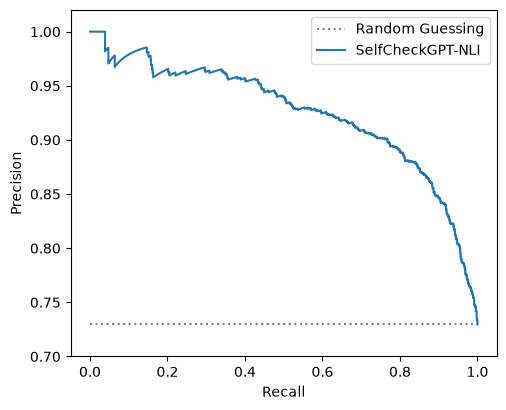

In [28]:
# with human label, Detecting Non-factual
plt.figure(figsize=(5.5, 4.5))
plt.hlines(y=random_baseline, xmin=0, xmax=1.0, color='grey', linestyles='dotted', label='Random Guessing') 
plt.plot(Rec, Prec, '-', label='SelfCheckGPT-NLI')
plt.legend()
plt.ylim(0.7,1.02)
plt.ylabel("Precision")
plt.xlabel("Recall")

## Experiment2: Detect False* (harder/less-trivial)

In [29]:
# with human label, Detecting False
Prec, Rec = get_PR_with_human_labels(selfcheck_scores, human_label_detect_False_h, pos_label=1)
print("-----------------------")
print("SelfCheckGPT-NLI on WikiBio")
print_AUC(Prec, Rec)

len: 1632
-----------------------
SelfCheckGPT-NLI on WikiBio
AUC: 45.16


In [30]:
arr = []
for v in human_label_detect_False_h.values():
    arr.extend(v)
random_baseline = np.mean(arr)
random_baseline

np.float64(0.2971813725490196)

Text(0.5, 0, 'Recall')

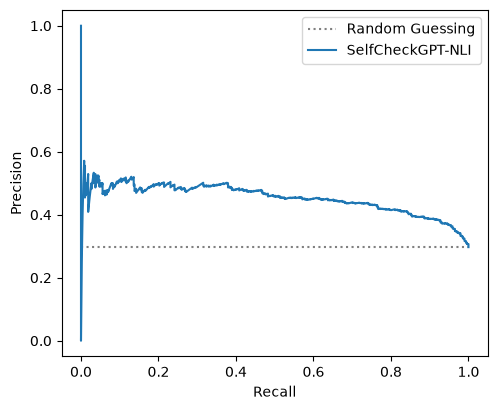

In [31]:
# with human label, Detecting Non-factual*
plt.figure(figsize=(5.5, 4.5))
plt.hlines(y=random_baseline, xmin=0, xmax=1.0, color='grey', linestyles='dotted', label='Random Guessing') 
plt.plot(Rec, Prec, '-', label='SelfCheckGPT-NLI')
plt.legend()
plt.ylabel("Precision")
plt.xlabel("Recall")

## Experiment3: Detecting True

In [32]:
# with human label, Detecting True
Prec, Rec = get_PR_with_human_labels(selfcheck_scores, human_label_detect_True, pos_label=1, oneminus_pred=True)
print("-----------------------")
print("SelfCheckGPT-NLI on WikiBio")
print_AUC(Prec, Rec)

len: 1908
-----------------------
SelfCheckGPT-NLI on WikiBio
AUC: 66.09


In [33]:
arr = []
for v in human_label_detect_True.values():
    arr.extend(v)
random_baseline = np.mean(arr)
random_baseline

np.float64(0.27044025157232704)

Text(0.5, 0, 'Recall')

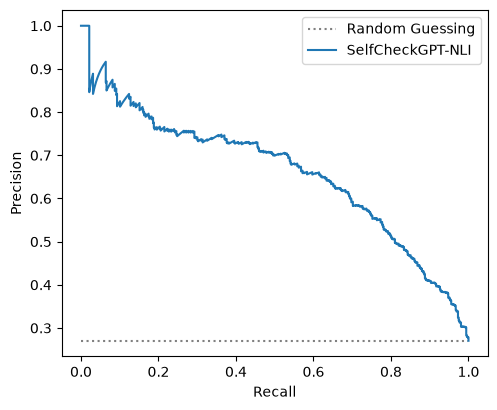

In [34]:
# with human label, Detecting Non-factual*
plt.figure(figsize=(5.5, 4.5))
plt.hlines(y=random_baseline, xmin=0, xmax=1.0, color='grey', linestyles='dotted', label='Random Guessing') 
plt.plot(Rec, Prec, '-', label='SelfCheckGPT-NLI')
plt.legend()
plt.ylabel("Precision")
plt.xlabel("Recall")

# Belief Stability vs SelfCheckGPT-NLI

`belief_scores` is in [-1, 1] (+1 = fully supported, -1 = fully
contradicted) - the OPPOSITE polarity from SelfCheckGPT-NLI's
P(contradiction) score (higher = more hallucinated). So "detect
False" (non-factual) uses `-belief_score` and "detect True"
(factual) uses `belief_score` directly. See
`belief_stability/evaluation.py` for the shared helpers used here
(the same ones `experiments/evaluate_belief.py` uses for the full
baseline/bayesian/graph ablation table).

In [35]:
belief_hallucination_scores = {
    idx: [-s for s in scores] for idx, scores in belief_scores.items()
}

# Experiment 1: Detecting False
Prec_bs, Rec_bs = get_PR_with_human_labels(
    belief_hallucination_scores, human_label_detect_False, pos_label=1
)
print("-----------------------")
print(f"Belief Stability ({belief_config.scoring_method}) on WikiBio - Detect False")
print_AUC(Prec_bs, Rec_bs)

# Experiment 2: Detect False* (harder/less-trivial)
Prec_bs_h, Rec_bs_h = get_PR_with_human_labels(
    belief_hallucination_scores, human_label_detect_False_h, pos_label=1
)
print("-----------------------")
print(f"Belief Stability ({belief_config.scoring_method}) on WikiBio - Detect False*")
print_AUC(Prec_bs_h, Rec_bs_h)

# Experiment 3: Detecting True (belief_scores already high == factual, no oneminus needed)
Prec_bs_t, Rec_bs_t = get_PR_with_human_labels(
    belief_scores, human_label_detect_True, pos_label=1
)
print("-----------------------")
print(f"Belief Stability ({belief_config.scoring_method}) on WikiBio - Detect True")
print_AUC(Prec_bs_t, Rec_bs_t)

len: 1908
-----------------------
Belief Stability (bayesian) on WikiBio - Detect False
AUC: 73.47
len: 1632
-----------------------
Belief Stability (bayesian) on WikiBio - Detect False*
AUC: 24.18
len: 1908
-----------------------
Belief Stability (bayesian) on WikiBio - Detect True
AUC: 38.81


len: 1908


Text(0.5, 1.0, 'Detect Non-Factual: SelfCheckGPT-NLI vs Belief Stability')

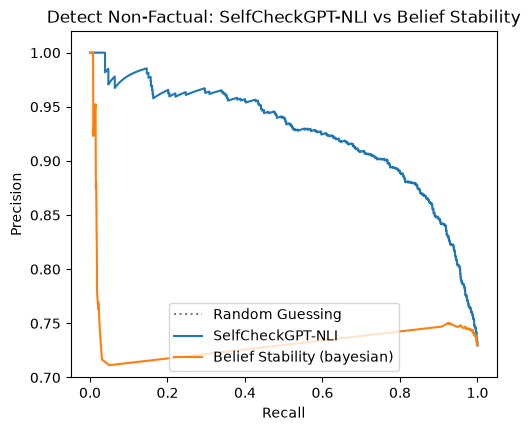

In [36]:
# PR curve: Belief Stability vs SelfCheckGPT-NLI on Detect-False.
# Recomputed fresh here (not reusing the notebook's Prec/Rec vars above -
# those get overwritten by each of Experiments 1/2/3 in turn, so by this
# point they hold Experiment 3's "Detect True" curve, not Detect-False).
Prec_sc_false, Rec_sc_false = get_PR_with_human_labels(
    selfcheck_scores, human_label_detect_False, pos_label=1
)

plt.figure(figsize=(5.5, 4.5))
plt.hlines(y=random_baseline, xmin=0, xmax=1.0, color='grey', linestyles='dotted', label='Random Guessing')
plt.plot(Rec_sc_false, Prec_sc_false, '-', label='SelfCheckGPT-NLI')
plt.plot(Rec_bs, Prec_bs, '-', label=f'Belief Stability ({belief_config.scoring_method})')
plt.legend()
plt.ylim(0.7, 1.02)
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.title("Detect Non-Factual: SelfCheckGPT-NLI vs Belief Stability")